# Caregiver Bot Analysis - Stakeholder View

This notebook answers four questions in plain language, in order:

1. **Does the screen work, and is it fair?** Where every cutoff came from, and what it costs in real caregivers wrongly held.
2. **What did it catch?** The rule applied to real responses, end to end.
3. **How is the queue made up?** Who is in each action group.
4. **What do we do about it?** Which checks are holding payments, where the screen is blind, and where to start.

Every section is one simple table or one simple chart. No statistics vocabulary, no rule codes -
each check is named in the words a reviewer would use.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

import bot_analysis as ba

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 90)

project_dir = Path.cwd()
output_dir = project_dir / "Caregiver Outputs"
cache_dir = project_dir / "data_cache"

# The published stakeholder views (action groups, timing summaries, workbook tables).
views = ba.build_stakeholder_views(output_dir, cache_dir)
stakeholder_records = views["stakeholder_records"]
workbook_action_summary = ba.build_workbook_action_summary(stakeholder_records)
workbook_key_metrics = ba.build_workbook_key_metrics(stakeholder_records)
workbook_timing_summary = ba.build_workbook_timing_summary(stakeholder_records)
study_action_summary = views["study_action_summary"]
flag_strength_summary = views["flag_strength_summary"]

# One record-level frame behind the screening-evidence sections below.
screen_inputs = ba.build_screen_inputs(output_dir, cache_dir)

print(f"Loaded {len(stakeholder_records):,} responses across both studies")
print(screen_inputs["Group"].value_counts().to_string())

Loaded 1,956 responses across both studies
Group
Online sign-ups           1779
Caregivers we verified     177


## The rule, in one line

> **We hold a payment when any serious check fires, or when two or more supporting checks fire together.
> One supporting check on its own means low-risk provisional approval. No checks at all means cleared for payment now.**

That single line sorts all 1,956 responses, with no exceptions and no manual overrides. The two tables below
show which checks count as serious, and where each cutoff number came from.

In [2]:
display(ba.build_decision_rule_table())

,What the check found,How seriously we treat it,What it takes to hold a payment
0,Whole survey too fast,Serious,Any one of these on its own holds the payment
1,Attitudes section too fast,Serious,Any one of these on its own holds the payment
2,Answer sheet identical to another response,Serious,Any one of these on its own holds the payment
3,Family answers contradict each other,Serious,Any one of these on its own holds the payment
4,Age and location cannot both be true,Serious,Any one of these on its own holds the payment
5,One section rushed,Supporting,Two or more of these together hold the payment
6,Same answer repeated down a block,Supporting,Two or more of these together hold the payment
7,Arrived within a minute of two or more others,Supporting,Two or more of these together hold the payment
8,Comment nearly identical to another,Supporting,Two or more of these together hold the payment


### Where every cutoff came from

None of these numbers were chosen. Every one was read off the 131 identity-verified caregivers who
finished all four sections - not one online sign-up contributed to any cutoff.

A note on the fastest-1-in-100 rows: for a speed limit, the fastest 1 in 100 is the quickest end of the
verified group, so the check fires only on responses quicker than almost every real caregiver we have.

In [3]:
display(ba.build_limit_origin_table(output_dir))

,What we check,The line we drew,How that line was worked out,Whose answers set it
0,Whole survey too fast,11 minutes 34 seconds,The fastest verified caregiver who finished every section,The 131 verified caregivers who finished every section
1,Attitudes section too fast,7 minutes 51 seconds,The fastest verified caregiver on that section,The 131 verified caregivers who finished every section
2,Family information section rushed,47 seconds,The fastest 1 in 100 verified caregivers on that section,The 131 verified caregivers who finished every section
3,Values section rushed,41 seconds,The fastest 1 in 100 verified caregivers on that section,The 131 verified caregivers who finished every section
4,Attitudes section rushed,8 minutes 34 seconds,The fastest 1 in 100 verified caregivers on that section,The 131 verified caregivers who finished every section
5,Demographics section rushed,1 minute 6 seconds,The fastest 1 in 100 verified caregivers on that section,The 131 verified caregivers who finished every section
6,Same answer repeated down a block,Answers varied less than 0.78 on a 1-4 block,The 1 in 100 verified caregivers whose answers varied least,The 131 verified caregivers who finished every section
7,Arrived within a minute of two or more others,3 or more sign-ups inside 60 seconds,The 1 in 100 shortest gaps between verified caregiver sign-ups,The 131 verified caregivers who finished every section


---
## Part 1 - Does the screen work, and is it fair?

Study 1 is an identity-verified caregiver sample, so it works as a control group: anything the screen
flags there is a caregiver we know is real being held up. Study 2 is the unverified online recruitment
that prompted this review.

### How fast can a real caregiver finish?

The dashed line is not a target anyone picked - it is the single fastest verified caregiver. Everyone
to the left of it finished faster than any real caregiver we have on record.

Only responses with all four sections timed can be placed on the whole-survey chart, because a partly
answered response has no end-to-end time to compare.

,Group,Responses we could time,Middle time (minutes),Fastest time (minutes),Faster than the line
0,Caregivers we verified - whole survey,131,26.69,11.57,0 of 131
1,Online sign-ups - whole survey,"1,575",20.87,3.80,"283 of 1,575"
2,Caregivers we verified - attitudes section,131,18.93,7.85,0 of 131
3,Online sign-ups - attitudes section,"1,587",12.22,2.05,"447 of 1,587"


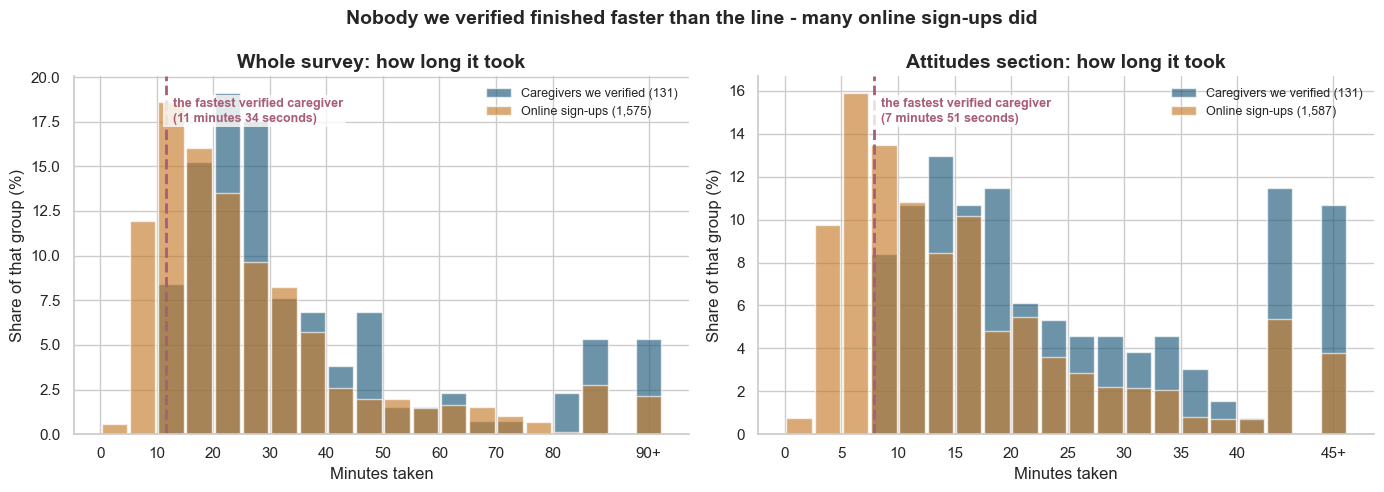

In [4]:
display(ba.build_speed_reference_table(screen_inputs))
ba.plot_speed_comparison(screen_inputs);

### What happens if we move the line

The section above is only convincing if the line is not rigged. Everything to the left of today's setting
is a guaranteed zero, because the line *is* the fastest verified caregiver - so the informative half of
this chart is the right-hand half, where moving the line starts costing real caregivers.

,Where we draw the line,"Online sign-ups caught (out of 1,587)",Caregivers we know are real caught by mistake (out of 131),What this setting means
0,4 minutes,80,0,"Catches nobody we know is real, but holds fewer sign-ups"
1,5 minutes,167,0,"Catches nobody we know is real, but holds fewer sign-ups"
2,6 minutes,260,0,"Catches nobody we know is real, but holds fewer sign-ups"
3,7 minutes,375,0,"Catches nobody we know is real, but holds fewer sign-ups"
4,7.85 minutes (today's setting),447,0,Today's setting - the last one that catches nobody we know is real
5,9 minutes,543,4,Moves 4 caregiver(s) we know are real into the hold pile
6,10 minutes,633,11,Moves 11 caregiver(s) we know are real into the hold pile
7,12 minutes,774,24,Moves 24 caregiver(s) we know are real into the hold pile
8,15 minutes,939,42,Moves 42 caregiver(s) we know are real into the hold pile


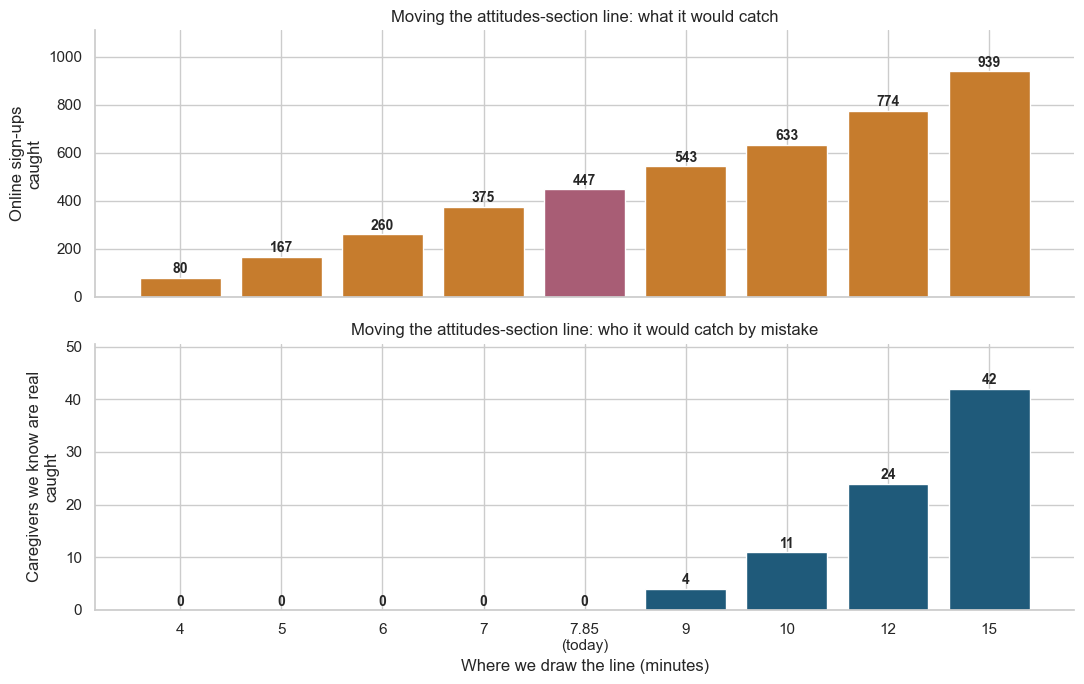

In [5]:
cutoff_sensitivity = ba.build_cutoff_sensitivity_table(screen_inputs)
display(cutoff_sensitivity)
ba.plot_cutoff_sensitivity(cutoff_sensitivity);

### Has any check ever flagged a caregiver we know is real?

The honest read: five of the nine checks have never flagged a verified caregiver, but 131 people is a
small test, so keep a route for someone to appeal.

Watch the fourth row. *Age and location cannot both be true* is a serious check - one hit alone holds a
payment - and it has fired exactly twice in all 1,956 responses, both times on an identity-verified
caregiver and never once on an online sign-up. It is worth re-checking those two records and deciding
whether the check should stay serious.

In [6]:
display(ba.build_wrong_flag_table(screen_inputs))

,The check,How seriously we treat it,Verified caregivers it flagged (out of 131),What that tells us,What to do with it
0,One section rushed,Supporting,6,Fires on 6 of 131 people we know are real.,"Use it to sort the queue, never on its own"
1,Same answer repeated down a block,Supporting,5,Fires on 5 of 131 people we know are real.,"Use it to sort the queue, never on its own"
2,Arrived within a minute of two or more others,Supporting,3,Fires on 3 of 131 people we know are real.,"Use it to sort the queue, never on its own"
3,Age and location cannot both be true,Serious,2,Fires on 2 of 131 people we know are real.,"Review this check - it has never fired on an online sign-up, only on people we know ar..."
4,Whole survey too fast,Serious,0,Zero here is partly guaranteed - this line was set at the fastest verified caregiver -...,Strong enough to act on with a quick spot check
5,Attitudes section too fast,Serious,0,Zero here is partly guaranteed - this line was set at the fastest verified caregiver -...,Strong enough to act on with a quick spot check
6,Answer sheet identical to another response,Serious,0,"This check has never fired on anyone, in either study.",Strong enough to act on with a quick spot check
7,Family answers contradict each other,Serious,0,"This check has never fired on anyone, in either study.",Strong enough to act on with a quick spot check
8,Comment nearly identical to another,Supporting,0,"This check has never fired on anyone, in either study.",Strong enough to act on with a quick spot check


---
## Part 2 - What did it catch?

### One response at a time, five real records

These are five actual responses from Study 2, not illustrations. Each row shows what was measured, what
fired, and how the rule read it. Record numbers can be looked up in the *Pay Now* and *Review Queue*
sheets of the exported workbook.

In [7]:
display(ba.build_worked_examples(screen_inputs))

,Response,Whole survey (minutes),Attitudes section (minutes),Checks it set off,How the rule reads it,Decision
0,1779,35.54,28.40,None,No concerns,Cleared for payment now
1,1243,30.84,21.28,Arrived within a minute of two or more others,One supporting check on its own,Low-risk provisional approval
2,1276,21.23,16.28,One section rushed; Arrived within a minute of two or more others,2 supporting checks together,Needs human review
3,1355,10.84,7.68,Whole survey too fast; Attitudes section too fast; One section rushed; Arrived within ...,2 serious and 2 supporting checks,Needs human review
4,1026,4.17,2.47,Whole survey too fast; Attitudes section too fast; Family answers contradict each othe...,3 serious and 3 supporting checks,Confirmed bot / reject


Reading the ladder: 1779 sets nothing off and is paid. 1243 trips one supporting check, which is not
enough to hold a payment. 1276 trips two supporting checks together, which is. 1355 finished the whole
survey faster than any verified caregiver - two serious checks - and is held. 1026 does everything 1355
does *and* contradicts itself on family information, which is the difference between being held for
review and being rejected outright.

Three of the six rejected responses broke the whole-survey line and three broke only the attitudes line,
so the shared pattern is "the survey, or its attitudes section, was faster than any verified caregiver",
not the whole-survey line alone.

### How many checks each response set off

This is the raw count the decision is built from. Two checks is the ceiling for everyone we
identity-verified - though that ceiling rests on 177 people, so treat it as the most we have ever seen
from a verified caregiver rather than a law.

,Number of checks set off,Caregivers we verified,Caregivers we verified (% of group),Online sign-ups,Online sign-ups (% of group)
0,0,153,86.4,70,3.9
1,1,21,11.9,662,37.2
2,2,3,1.7,411,23.1
3,3,0,0.0,275,15.5
4,4,0,0.0,239,13.4
5,5,0,0.0,114,6.4
6,6,0,0.0,8,0.4


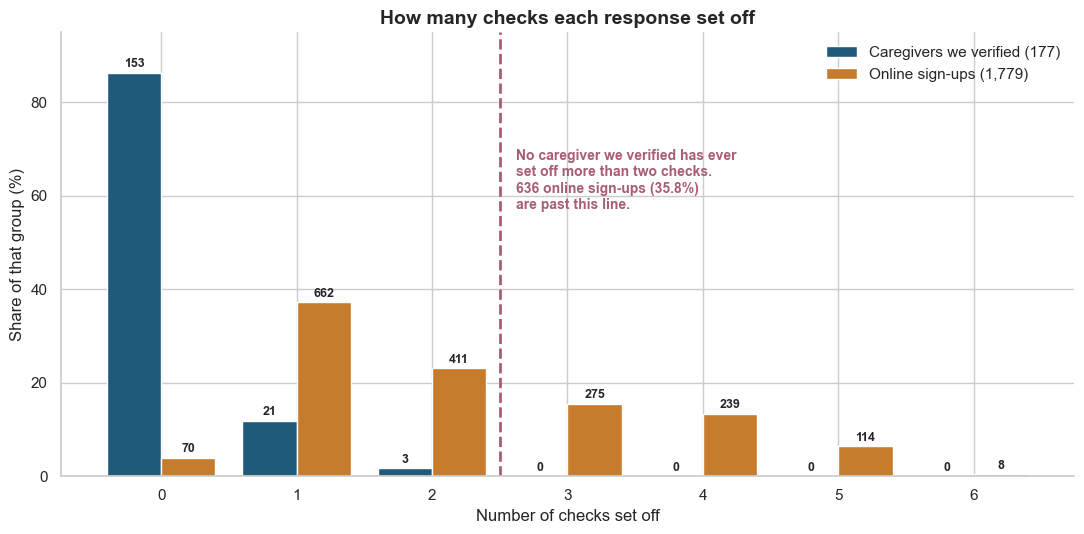

In [8]:
display(ba.build_checks_set_off_table(screen_inputs))
ba.plot_checks_set_off(screen_inputs);

### How often each check fired

Both studies side by side, so a check that fires on everyone is easy to spot. *Arrived within a minute of
two or more others* fires on 94.2% of online sign-ups, which makes it excellent at separating the two
studies and nearly useless for ranking responses inside Study 2 - almost everyone has it.

,The check,How seriously we treat it,"Online sign-ups it fired on (out of 1,779)",Share of online sign-ups,Caregivers we verified it fired on (out of 177)
0,Arrived within a minute of two or more others,Supporting,1676,94.2%,6
1,One section rushed,Supporting,839,47.2%,7
2,Same answer repeated down a block,Supporting,577,32.4%,12
3,Attitudes section too fast,Serious,447,25.1%,0
4,Whole survey too fast,Serious,283,15.9%,0
5,Family answers contradict each other,Serious,44,2.5%,0
6,Comment nearly identical to another,Supporting,17,1.0%,0
7,Answer sheet identical to another response,Serious,0,0.0%,0
8,Age and location cannot both be true,Serious,0,0.0%,2


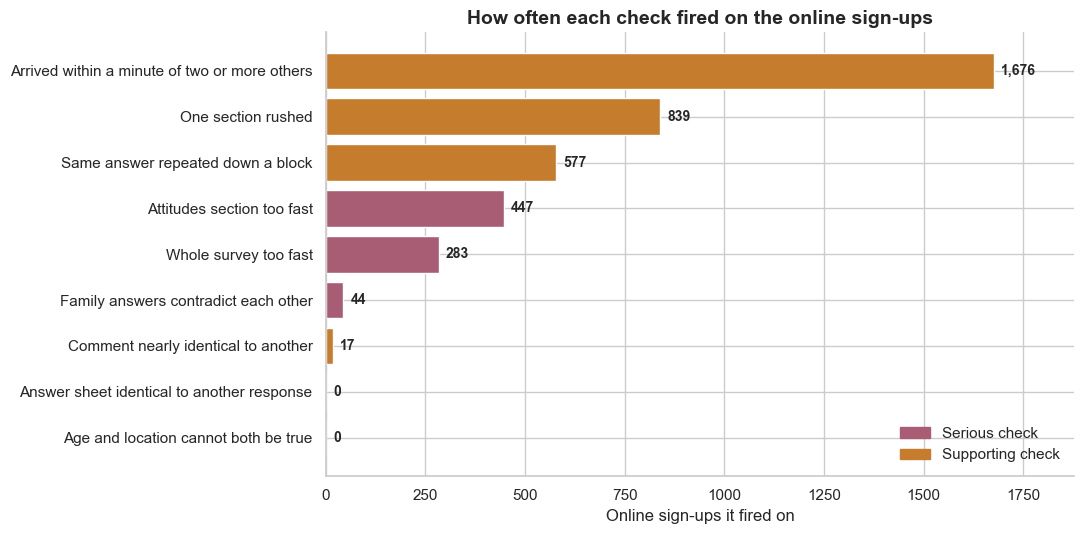

In [9]:
display(ba.build_all_checks_frequency_table(screen_inputs))
ba.plot_all_checks_frequency(screen_inputs);

### When the responses arrived

The two panels use different scales on purpose - a shared axis would flatten Study 1 to a hairline.

Payment Decision,When it arrived,Responses,Cleared for payment now,Low-risk provisional approval,Needs human review,Confirmed bot / reject
0,The three days before it,57,36,10,11,0
1,Surge day (06 Sep),1722,34,650,1032,6


On 06 Sep 2025, 1,722 of the 1,779 online sign-ups arrived - 1,717 of them inside four hours.
Half of them arrived within 4 seconds of the one before, against about 11 minutes for the verified caregivers.


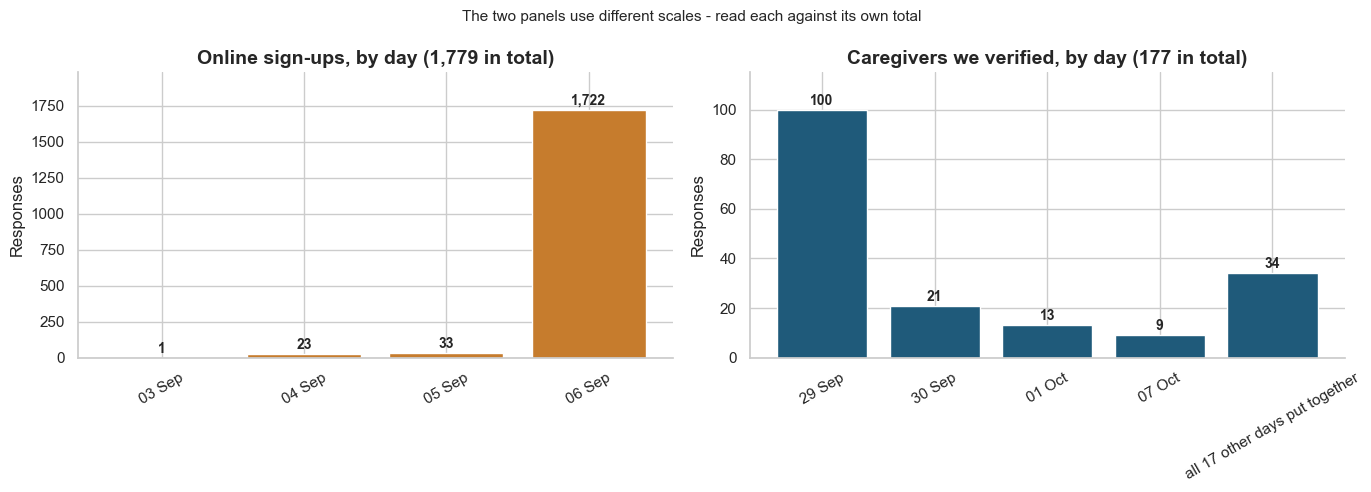

In [10]:
arrival = ba.build_arrival_tables(screen_inputs)
facts = arrival["surge_facts"]

display(arrival["surge_crosstab"])

print(
    f"On {facts['surge_day']:%d %b %Y}, {facts['surge_n']:,} of the {facts['online_n']:,} online "
    f"sign-ups arrived - {facts['busiest_n']:,} of them inside four hours."
)
print(
    f"Half of them arrived within {facts['median_gap_seconds']:.0f} seconds of the one before, "
    f"against about {facts['verified_median_gap_minutes']:.0f} minutes for the verified caregivers."
)
ba.plot_arrival_pattern(screen_inputs);

The three days before the surge are a thin base - 57 responses - so treat this as a strong hint rather
than a measurement. Even so, those 57 days produced 36 clear passes, while the single surge day produced
1,032 of the 1,043 responses now waiting for review. Note that 11 of the 57 still went to review, so
arrival date on its own clears nothing.

---
## Part 3 - How the queue is made up

The action groups, the split by study, and what sits inside the flagged queue.

In [11]:
display(workbook_action_summary)
display(workbook_key_metrics)
display(workbook_timing_summary)

,Action group,Records,Share of all responses,What to do
0,Pay now,223,11.4%,Send gift card now
1,Low-risk approval,679,34.7%,Approve after quick check
2,Review,1048,53.6%,Hold for human review
3,Do not pay,6,0.3%,Do not pay


,Metric,Value,Why it matters
0,All responses reviewed,"1,956",Both studies combined.
1,Study 2 responses,"1,779",Main focus of the stakeholder bot review.
2,Need manual review or do not pay,"1,054",Highest-priority records for next-step review.
3,Broke both time limits,279,Records under both speed cutoffs.
4,Broke both time limits only,276,These 276 had no other major issue flagged.


,Action group,Study 2 records,Median full survey time,Median attitudes time
0,Pay now,70,35.54 min,23.35 min
1,Low-risk approval,660,30.23 min,19.65 min
2,Review,1043,15.25 min,8.52 min
3,Do not pay,6,9.63 min,4.40 min


The median times above are calculated on whatever sections a response actually timed, so they describe
each group rather than reproducing the cutoff test. The cutoff test itself needs all four sections and
is the one shown in Part 1.

,Study,Action group,Records,Share within study (%),What to do
0,Study 1 - Verified (4797),Pay now,153,86.4,Send gift card now
1,Study 1 - Verified (4797),Low-risk approval,19,10.7,Approve after quick check
2,Study 1 - Verified (4797),Review,5,2.8,Hold for human review
3,Study 1 - Verified (4797),Do not pay,0,0.0,Do not pay
4,Study 2 - Legacy (4581),Pay now,70,3.9,Send gift card now
5,Study 2 - Legacy (4581),Low-risk approval,660,37.1,Approve after quick check
6,Study 2 - Legacy (4581),Review,1043,58.6,Hold for human review
7,Study 2 - Legacy (4581),Do not pay,6,0.3,Do not pay


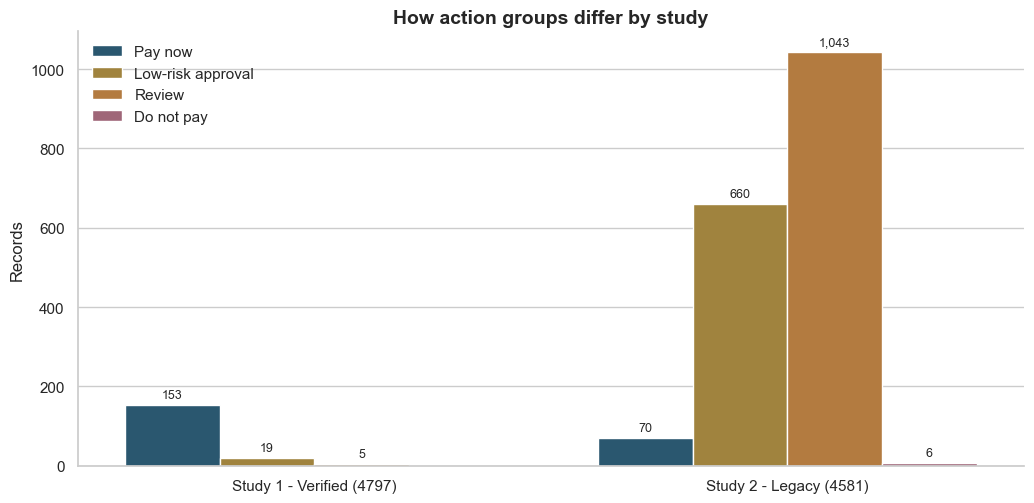

In [12]:
display(study_action_summary)
ba.plot_workbook_study_action_comparison(stakeholder_records);

### How severe is the flagged queue?

Not every held response is equally concerning. The signal mix itself is already shown, on the full Study 2
denominator, in *How often each check fired* above - this table adds the part that chart cannot show:
how many **serious** checks each held response carries.

In [13]:
display(flag_strength_summary)

,Flag pattern in Study 2 queue,Records,Share of review queue (%),How to read it
0,Soft-only review,560,53.4,No major issue; these records entered review because softer signals piled up.
1,One major issue,207,19.7,"One strong signal is present, but not enough for an outright rejection."
2,Two major issues,279,26.6,Two strong signals on the same record; this is the clearest review cluster.
3,Three or more major issues,3,0.3,Very concentrated concern; this is the most severe tail of the queue.


---
## Part 4 - What do we do about it?

### Which checks are actually holding payments

Two different things: how often a check fired, and how often it was the *only* concern on a response.
The last column is recomputed by re-running the rule with that check removed, so it is measured rather
than assumed. The two bars sit on different totals, so their lengths are not a ratio.

,The check,How seriously we treat it,Times it fired on online sign-ups,Times it was the only concern on the response,Payments it would release if we switched it off
0,Arrived within a minute of two or more others,Supporting,1676,641,400
1,One section rushed,Supporting,839,6,216
2,Same answer repeated down a block,Supporting,577,13,189
3,Attitudes section too fast,Serious,447,0,0
4,Whole survey too fast,Serious,283,0,1
5,Family answers contradict each other,Serious,44,2,9
6,Comment nearly identical to another,Supporting,17,0,1


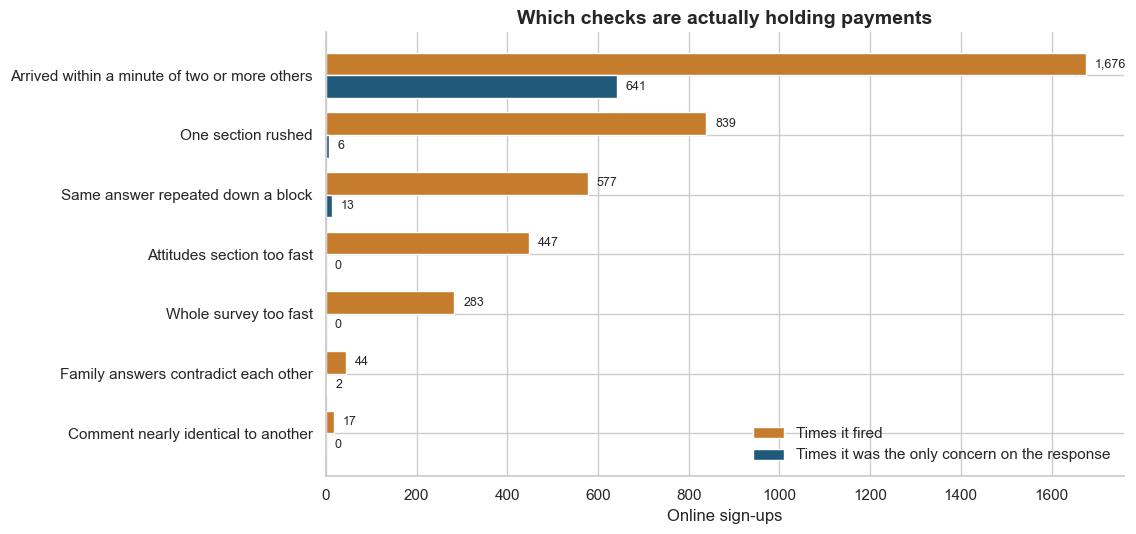

In [14]:
check_impact = ba.build_check_impact_table(screen_inputs)
display(check_impact)
ba.plot_check_impact(check_impact);

Switching off *Arrived within a minute of two or more others* would release 400 held payments and clear
641 more outright, because responses sitting on exactly two supporting checks would drop to one. That is
the largest single lever in the screen, and it is a supporting check.

### Where no check can reach

Every timing check needs a timing to fire. These four groups are mutually exclusive and add to 1,779.

In [15]:
display(ba.build_timing_coverage_table(screen_inputs))

,What we were able to time,Responses,Approved to pay,Held for review or rejected
0,All four sections timed,1575,574,1001
1,"Some sections timed, attitudes section missing",81,40,41
2,"Some sections timed, one other section missing",12,5,7
3,No timing at all,111,111,0


All 111 responses in the bottom row cleared the sign-up screener and then answered a median of **zero**
survey questions - family information, values, attitudes and demographics are all marked not started -
and every one of them is approved to pay, 19 of them fully cleared. Nothing has been disbursed, but no
timing check can fire on a blank form. This is a fixable gap in the rule set, not a judgement call.

### Where to start, and what it costs

Worst-first batches of the 1,043 responses waiting for review. The 8 minutes per response is a planning
assumption you can change - at 5 minutes the whole queue is 87 hours, at 15 minutes it is 261. Every
other number comes from the data.

In [16]:
display(ba.build_work_plan_table(screen_inputs, minutes_per_response=8))

,"Batch, worst first",Responses in this batch,Responses checked once this batch is done,"Responses that beat the fastest verified caregiver, found so far",Hours of staff time at 8 minutes each,Responses still unchecked
0,Set off 5 or 6 checks,117,117,117 of 445,16,926
1,Set off 4 checks,238,355,353 of 445,47,688
2,Set off 3 checks,275,630,444 of 445,84,413
3,Set off 2 checks or fewer,413,1043,445 of 445,139,0


Working the worst 630 responses - about 84 hours - reaches 444 of the 445 that finished faster than any
verified caregiver. The 413 responses below the cut are **not** cleared; they are in the queue for
rushed-section and repeated-answer reasons and nobody has looked at them.

---
## Workbook export

Rebuilds the stakeholder workbook so the notebook and the exported file stay aligned.

In [17]:
stakeholder_workbook = ba.export_stakeholder_excel(output_dir=output_dir, cache_dir=cache_dir)
print(f"Workbook written: {stakeholder_workbook.name}")
print(pd.ExcelFile(stakeholder_workbook).sheet_names)

Workbook written: ESD_Bot_Analysis_Stakeholder_Summary.xlsx
['Summary', 'Pay Now', 'Review Queue', 'Screen Guide', 'Extra Views']


---
## What the numbers say

**The screen holds up.** Every cutoff was set from the 131 verified caregivers, and at today's settings
the two speed checks flag none of them while flagging 283 and 447 online sign-ups. Moving the attitudes
line out by one step, to 9 minutes, adds 96 sign-ups but sweeps in 4 caregivers we know are real - so the
current setting is the last one that costs nothing.

**Two checks is the ceiling for a verified caregiver.** 636 online sign-ups (35.8%) set off three or
more; 8 set off six of the nine.

**The arrival pattern is the strongest single signal.** 1,722 of 1,779 online sign-ups arrived on one
day, 1,717 of them within four hours, half of them within 4 seconds of the one before. That one day
produced 1,032 of the 1,043 responses now waiting for review.

**Three things to decide next:**

1. *Age and location cannot both be true* is a serious check that has only ever fired on two verified
   caregivers and never on an online sign-up. Re-check those two records and decide whether it stays serious.
2. 111 responses are approved to pay having answered no survey questions at all. No timing check can
   reach them. Add a completion check before any payment run.
3. *Arrived within a minute of two or more others* fires on 94.2% of Study 2 and is the only concern on
   641 responses. It is doing most of the holding, and it is a supporting check - confirm that is intended
   before working the queue.

**One caveat to carry forward.** The `Total Survey Time (min)` column in the record export adds up
whichever sections a response timed, so a partly answered response shows a small partial total that never
triggered the speed check. Part 1 uses the strict end-to-end total instead. The timing images in the
exported workbook (*Summary* and *Extra Views*) still use the partial total, so they should be
regenerated from the strict one before that file is circulated.